# Logistic Regression Classifier

1.  [Imports](#scrollTo=BEVxN4lbmskd)
2.  [Dataset Preparation](#scrollTo=1v0BWzLunSCM)
3.  [Logistic Regression Model - Training, Evaluation](#scrollTo=BBB7Ikb3oKFR)
4.  [Hyperparameter Tuning](#scrollTo=McHmsKtco_sP)
5.  [Advanced Logistic Regression Models](#scrollTo=Dxd4yok-p1Qm)
6.  [Model Evaluation](#scrollTo=JaifUi_j3x_f)
7. [Conclusion](#scrollTo=YzhBJ8gGzM04)
8. [References](#scrollTo=cirXE9VFyPOj)
9.  *(Optional)* [Logistic Regression with Statsmodels](#scrollTo=pDcbYRsNqhtS)
10.  *(Optional)* [Feature Importance](#scrollTo=ZJ6Vk0Mq1zHl)

# 1. Imports

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
)

# For permutation importance
from sklearn.inspection import permutation_importance

# For statistical modeling
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 2. Dataset Preparation

## 2.1. Loading Dataset

In [2]:
# Load the Breast Cancer dataset
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display the first five rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2.2 Dataset Overview

In [3]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFeature Names:", data.feature_names)
print("\nTarget Classes:", data.target_names)

Dataset Shape: (569, 31)

Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Classes: ['malignant' 'benign']


## Check Class Distribution

In [4]:
df['target'].value_counts(normalize=True)

,proportion
target,
1,0.627417
0,0.372583


*The dataset is relatively balanced (67/37), making it suitable for binary classification without imbalance concerns.*

## 2.3 Data Preprocessing

**Proper preprocessing is crucial for Logistic Regression to ensure that features contribute equally to the model.**

In [34]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


**Logistic Regression benefits from feature scaling, especially when regularization is applied.**

**We'll standardize the features using StandardScaler.**

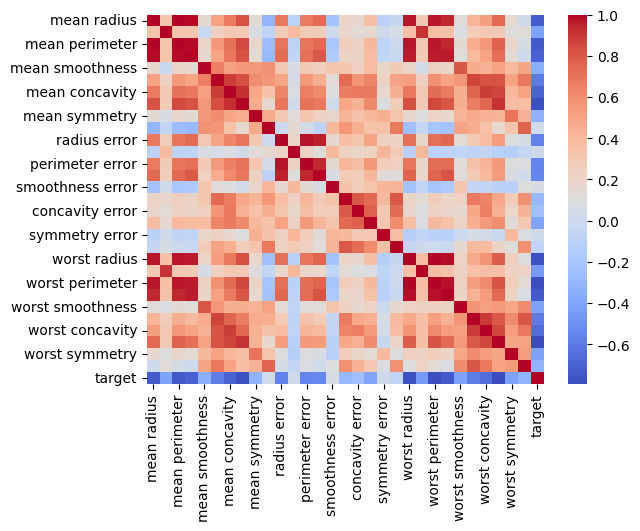

In [6]:
# check correlation
# draw correlation as heatmap
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def remove_highly_correlated_features(df, threshold=0.8):
    """
    Identifies and removes features from the DataFrame that have a correlation
    higher than the specified threshold.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing features.
    - threshold (float): The correlation threshold above which features are considered highly correlated.

    Returns:
    - pd.DataFrame: A DataFrame with highly correlated features removed.
    """
    # Compute the correlation matrix
    corr_matrix = df.corr().abs()

    # Select the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find features with correlation greater than the threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"Features to drop (correlation > {threshold}): {to_drop}")

    # Drop the features
    df_reduced = df.drop(columns=to_drop)

    return df_reduced

# Optional: Visualize the correlation matrix before and after feature removal
def plot_correlation_matrix(df, title):
    """
    Plots the correlation matrix of the DataFrame.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - title (str): Title of the plot.
    """
    plt.figure(figsize=(12, 10))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
    plt.title(title)
    plt.show()

Features to drop (correlation > 0.8): ['mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'perimeter error', 'area error', 'concavity error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst compactness', 'worst concavity', 'worst concave points', 'worst fractal dimension']
Original number of features: 30
Reduced number of features: 14


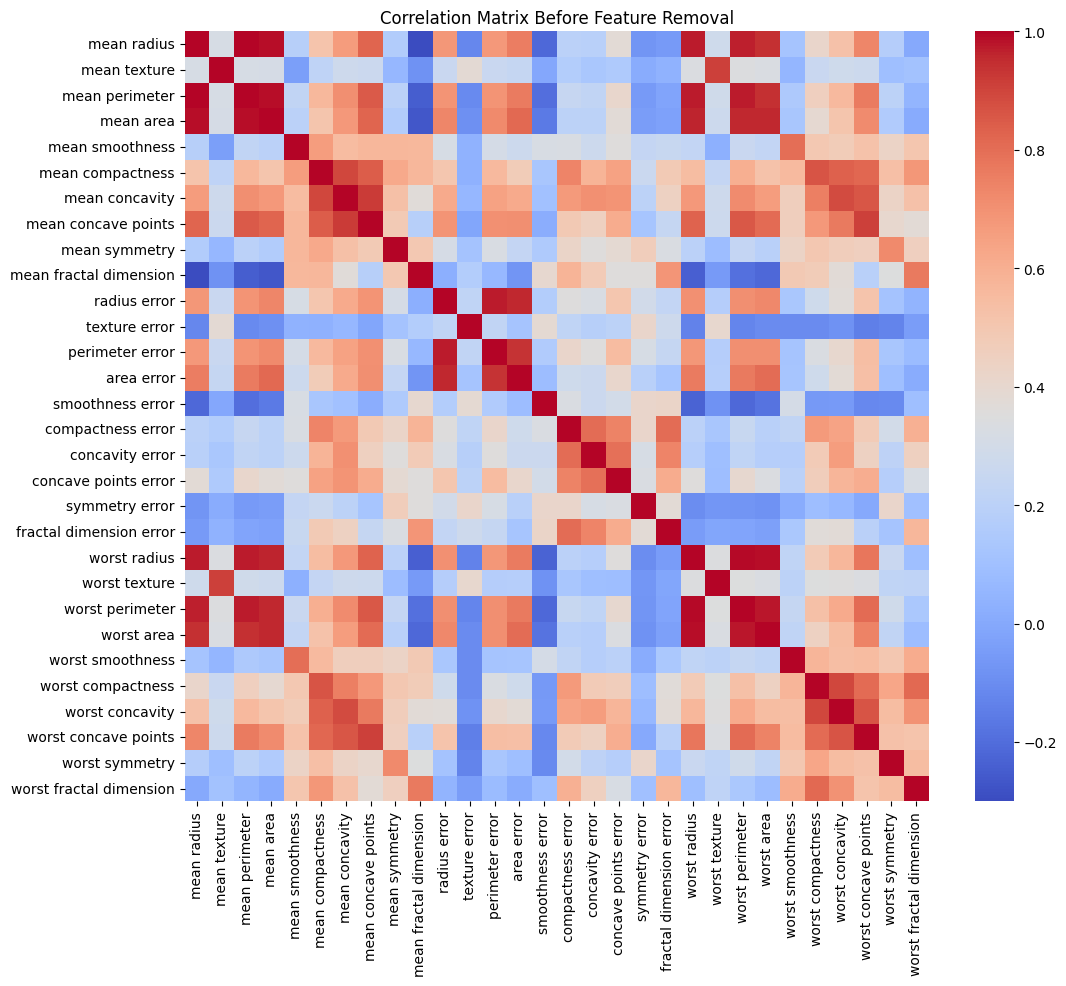

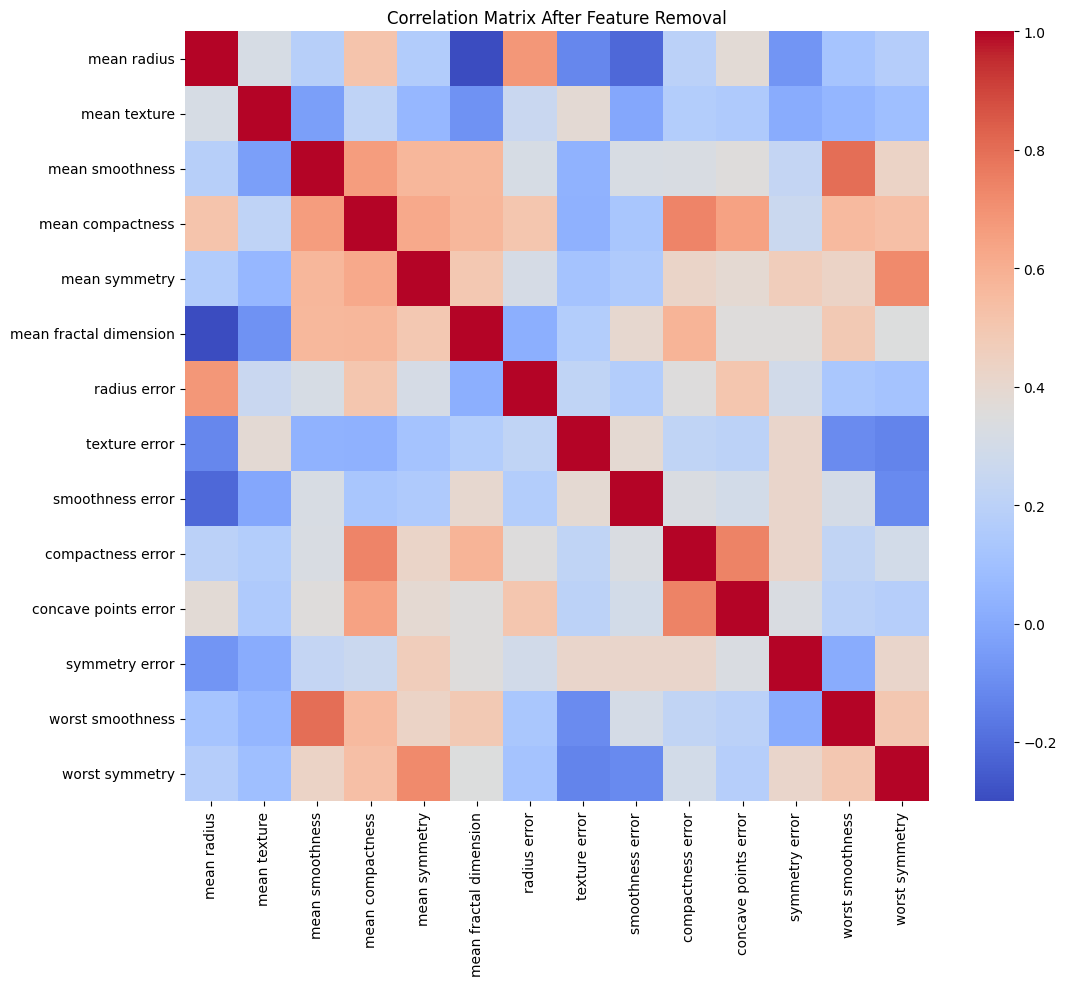

In [8]:
# Example Usage:
X_train_reduced = remove_highly_correlated_features(X_train, threshold=0.8)
X_test_reduced = X_test[X_train_reduced.columns]

# Display the shape before and after removing correlated features
print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of features: {X_train_reduced.shape[1]}")

# Plot before removing correlated features
plot_correlation_matrix(X_train, 'Correlation Matrix Before Feature Removal')

# Plot after removing correlated features
plot_correlation_matrix(X_train_reduced, 'Correlation Matrix After Feature Removal')


In [9]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data
X_train_scaled = scaler.fit_transform(X_train_reduced)

# Transform testing data
X_test_scaled = scaler.transform(X_test_reduced)

# 3. Logistic Regression Model - Training, Evaluation

## 3.1 Basic Logistic Regression with Default Parameters

Accuracy: 0.92


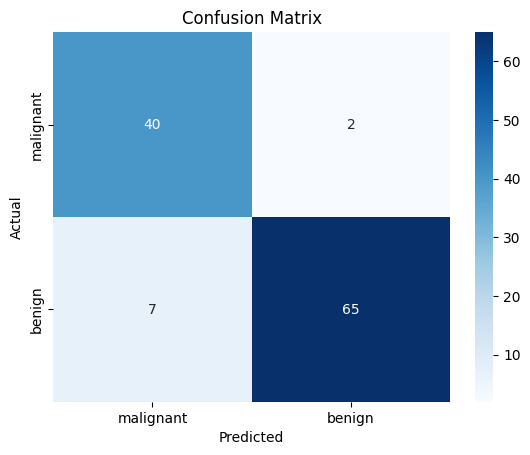

              precision    recall  f1-score   support

   malignant       0.85      0.95      0.90        42
      benign       0.97      0.90      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.93      0.92       114
weighted avg       0.93      0.92      0.92       114



In [10]:
# Initialize Logistic Regression with default parameters
logreg = LogisticRegression(penalty=None, max_iter=100, random_state=42)

# Fit the model
logreg.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = logreg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 4. Hyperparameter Tuning

## GridSearch for Optimal Regularization Parameter

In [11]:
# Define the parameter grid
param_grid = {
    'C': np.logspace(-4, 4, 20),  # Inverse of regularization strength
    'penalty': ['l2', None],  # Only l2 penalty is supported by default solvers
    'solver': ['lbfgs', 'liblinear']  # Different solvers handle penalties differently
}

# Initialize GridSearchCV
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit the grid search
grid.fit(X_train_scaled, y_train)

# Best parameters
print(f"Best parameters: {grid.best_params_}")

# Best cross-validation accuracy
print(f"Best cross-validation accuracy: {grid.best_score_:.2f}")

Best parameters: {'C': 0.08858667904100823, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.98


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
100 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1194, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "

## Retrain with Optimal Parameters

In [12]:
# Get the best parameters
best_params = grid.best_params_

# Initialize Logistic Regression with best parameters
logreg_best = LogisticRegression(**best_params, random_state=42)

# Fit the model
logreg_best.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_best = logreg_best.predict(X_test_scaled)

# Evaluate
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy with Optimal Parameters: {accuracy_best:.2f}")

Test Accuracy with Optimal Parameters: 0.96


## Cross-Validation Scores

In [13]:
# Cross-validation scores using StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_skf = cross_val_score(logreg_best, X_train_scaled, y_train, cv=skf, scoring='accuracy')

# Cross-validation scores using KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_kf = cross_val_score(logreg_best, X_train_scaled, y_train, cv=kf, scoring='accuracy')

print(f"Mean CV Accuracy (StratifiedKFold): {cv_scores_skf.mean():.2f}")
print(f"Mean CV Accuracy (KFold): {cv_scores_kf.mean():.2f}")

Mean CV Accuracy (StratifiedKFold): 0.97
Mean CV Accuracy (KFold): 0.97


# 5. Advanced Logistic Regression Models

## 5.1 Regularization Techniques

Regularization helps in preventing overfitting by penalizing large coefficients. Logistic Regression in scikit-learn supports different types of regularization:

- **L1 Regularization (`penalty='l1'`)**: Encourages sparsity (feature selection).
- **L2 Regularization (`penalty='l2'`)**: Encourages smaller coefficients.
- **Elastic Net (`penalty='elasticnet'`)**: Combines L1 and L2 penalties.

### 5.1.1 L1 Regularization (Feature Selection)

In [14]:
# Define parameter grid for L1 regularization
param_grid_l1 = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['l1'],
    'solver': ['liblinear', 'saga']  # 'liblinear' and 'saga' support L1
}

# Initialize GridSearchCV for L1
grid_l1 = GridSearchCV(
    LogisticRegression(max_iter=100, random_state=42),
    param_grid_l1,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the grid search
grid_l1.fit(X_train_scaled, y_train)

# Best parameters
print(f"L1 Best parameters: {grid_l1.best_params_}")

# Best cross-validation accuracy
print(f"L1 Best cross-validation accuracy: {grid_l1.best_score_:.2f}")

# Retrain with best parameters
logreg_l1 = LogisticRegression(**grid_l1.best_params_, random_state=42)
logreg_l1.fit(X_train_scaled, y_train)
y_pred_l1 = logreg_l1.predict(X_test_scaled)
accuracy_l1 = accuracy_score(y_test, y_pred_l1)
print(f"Test Accuracy with L1 Regularization: {accuracy_l1:.2f}")

# Feature Coefficients
coefficients_l1 = pd.Series(logreg_l1.coef_[0], index=X_train_reduced.columns)
selected_features_l1 = coefficients_l1[coefficients_l1 != 0].sort_values()
print("Selected Features with L1 Regularization:")
print(selected_features_l1)

L1 Best parameters: {'C': 0.615848211066026, 'penalty': 'l1', 'solver': 'saga'}
L1 Best cross-validation accuracy: 0.98
Test Accuracy with L1 Regularization: 0.95
Selected Features with L1 Regularization:
mean radius            -3.894362
radius error           -1.730881
worst smoothness       -1.596911
worst symmetry         -1.499907
mean texture           -1.284137
concave points error   -0.438613
compactness error       0.084108
smoothness error        0.185177
symmetry error          0.795941
dtype: float64


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 5.1.2 Elastic Net Regularization

In [15]:
# Define parameter grid for Elastic Net
param_grid_elastic = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['elasticnet'],
    'solver': ['saga'],  # 'saga' supports elasticnet
    'l1_ratio': [0.2, 0.5, 0.8]  # Balance between L1 and L2
}

# Initialize GridSearchCV for Elastic Net
grid_elastic = GridSearchCV(
    LogisticRegression(max_iter=100, random_state=42),
    param_grid_elastic,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the grid search
grid_elastic.fit(X_train_scaled, y_train)

# Best parameters
print(f"Elastic Net Best parameters: {grid_elastic.best_params_}")

# Best cross-validation accuracy
print(f"Elastic Net Best cross-validation accuracy: {grid_elastic.best_score_:.2f}")

# Retrain with best parameters
logreg_elastic = LogisticRegression(**grid_elastic.best_params_, random_state=42)
logreg_elastic.fit(X_train_scaled, y_train)
y_pred_elastic = logreg_elastic.predict(X_test_scaled)
accuracy_elastic = accuracy_score(y_test, y_pred_elastic)
print(f"Test Accuracy with Elastic Net Regularization: {accuracy_elastic:.2f}")

Elastic Net Best parameters: {'C': 0.23357214690901212, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}
Elastic Net Best cross-validation accuracy: 0.97
Test Accuracy with Elastic Net Regularization: 0.96


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 5.2 Multinomial Logistic Regression

While the Breast Cancer dataset is a binary classification problem, Logistic Regression can be extended to multiclass scenarios using the `multinomial` option.

In [16]:
# Note: Since the current dataset is binary, this is illustrative.
# For a multiclass dataset, you would set multi_class='multinomial'

# Initialize Logistic Regression with multinomial option
logreg_multinomial = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=100,
    random_state=42
)

# Fit the model
logreg_multinomial.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_multinomial = logreg_multinomial.predict(X_test_scaled)

# Evaluate
accuracy_multinomial = accuracy_score(y_test, y_pred_multinomial)
print(f"Multinomial Logistic Regression Accuracy: {accuracy_multinomial:.2f}")

# Classification Report
print(classification_report(y_test, y_pred_multinomial, target_names=data.target_names))

Multinomial Logistic Regression Accuracy: 0.94
              precision    recall  f1-score   support

   malignant       0.87      0.98      0.92        42
      benign       0.99      0.92      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.94      0.94      0.94       114



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


*Since the Breast Cancer dataset is binary, the multinomial option behaves similarly to the binary logistic regression.*

# 6. Model Evaluation

### Accuracy Score

In [17]:
accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.96


### Confusion Matrix

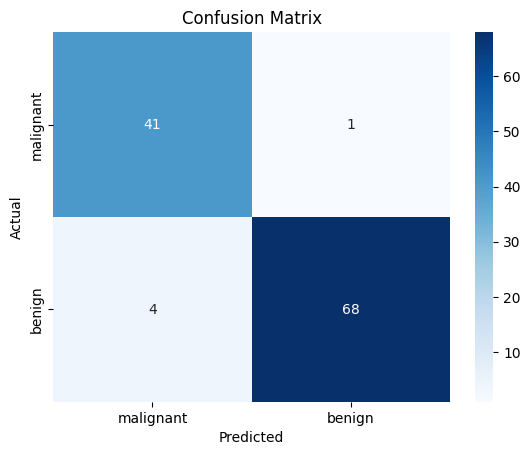

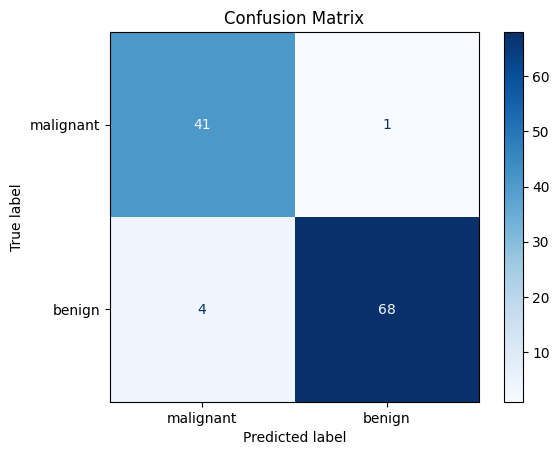

In [18]:
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names).plot(
    cmap='Blues', values_format='d'
)
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [19]:
# Classification Report
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



### Estimate Probabilities

Logistic Regression inherently estimates probabilities, which can be used for various evaluation metrics like ROC and Precision-Recall curves.


In [20]:
# Predict probabilities for ROC
y_proba = logreg_best.predict_proba(X_test_scaled)[:,1]

### Receiver Operator Characteristic Curve (ROC Curve)

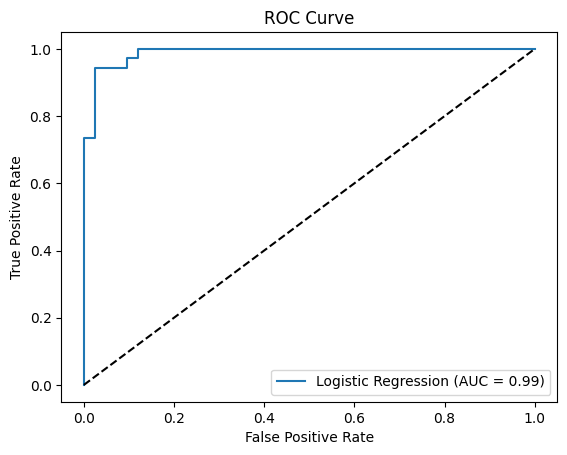

In [21]:
# Compute ROC curve and AUC
def plot_roc_curve_custom(y_true, y_prob, model_name='Logistic Regression'):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], 'k--')  # Diagonal
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

plot_roc_curve_custom(y_test, y_proba)

### Precision-Recall Curve and Average Precision

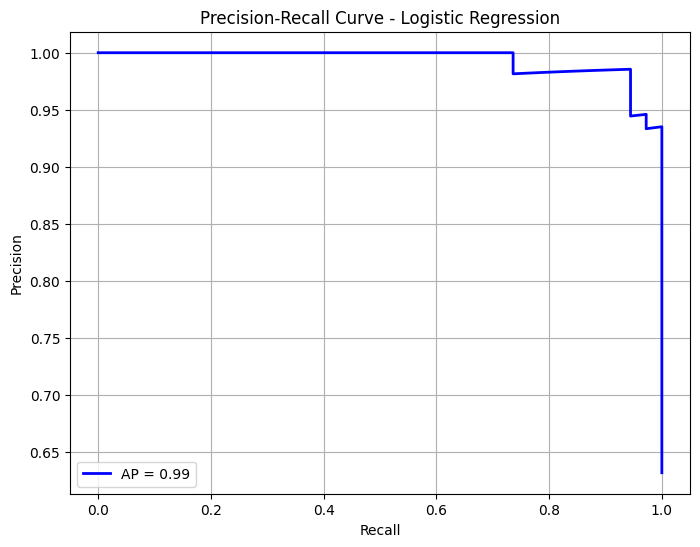

In [22]:
def plot_precision_recall_curve_custom(y_true, y_prob, model_name='Logistic Regression', pos_label=1):
    """
    Plots the Precision-Recall curve for a binary classifier.

    Parameters:
    - y_true: array-like of shape (n_samples,), ground truth binary labels (0 or 1)
    - y_prob: array-like of shape (n_samples,), predicted scores or probabilities for the positive class
    - model_name: str, name of the model for labeling
    - pos_label: int, the label of the positive class (default is 1)
    """
    # Calculate precision-recall pairs for different probability thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob, pos_label=pos_label)
    avg_precision = average_precision_score(y_true, y_prob)

    # Plot Precision-Recall curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', linewidth=2, label=f'AP = {avg_precision:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()

    return avg_precision

avg_precision = plot_precision_recall_curve_custom(y_test, y_proba)

### Class Score Distribution

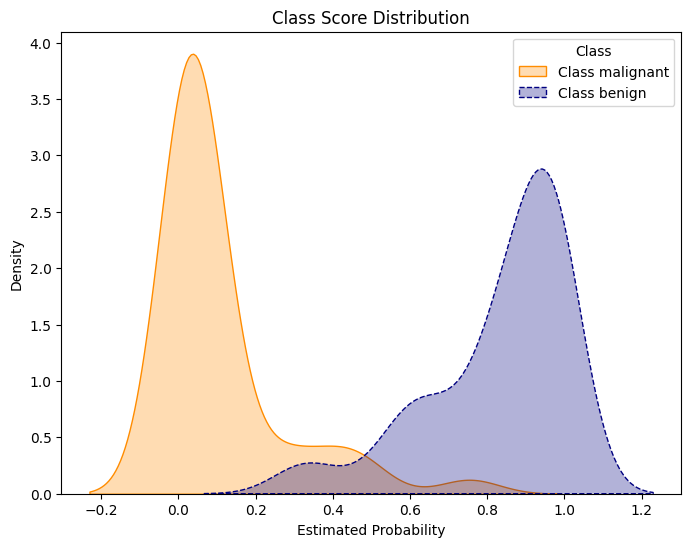

In [23]:
def plot_class_score_distribution(y_true, y_prob):
    """
    Plots the class score distribution for two classes based on two arrays.

    Parameters:
    - y_true: array-like, ground truth binary labels (0 or 1)
    - y_prob: array-like, predicted scores or probabilities for the positive class
    """
    plt.figure(figsize=(8, 6))

    # Plot KDE for each class
    for class_value, color, linestyle in zip(np.unique(y_true), ['darkorange', 'navy'], ['-', '--']):
        subset_scores = y_prob[np.array(y_true) == class_value]
        sns.kdeplot(
            subset_scores,
            color=color,
            linestyle=linestyle,
            label=f'Class {data.target_names[class_value]}',
            fill=True,
            alpha=0.3
        )

    # Add legend, labels, and title
    plt.legend(title="Class")
    plt.xlabel('Estimated Probability')
    plt.ylabel('Density')
    plt.title('Class Score Distribution')
    plt.show()

plot_class_score_distribution(y_test, y_proba)

### Average Precision (AP) Interpretation

*Average Precision (AP) is a single-number summary of the Precision-Recall (PR) curve, representing the area under the PR curve. It captures how well a binary classifier distinguishes positive from negative examples, especially in imbalanced datasets.*


### Estimating Optimal Threshold

#### Optimal Threshold Based on F1 Score

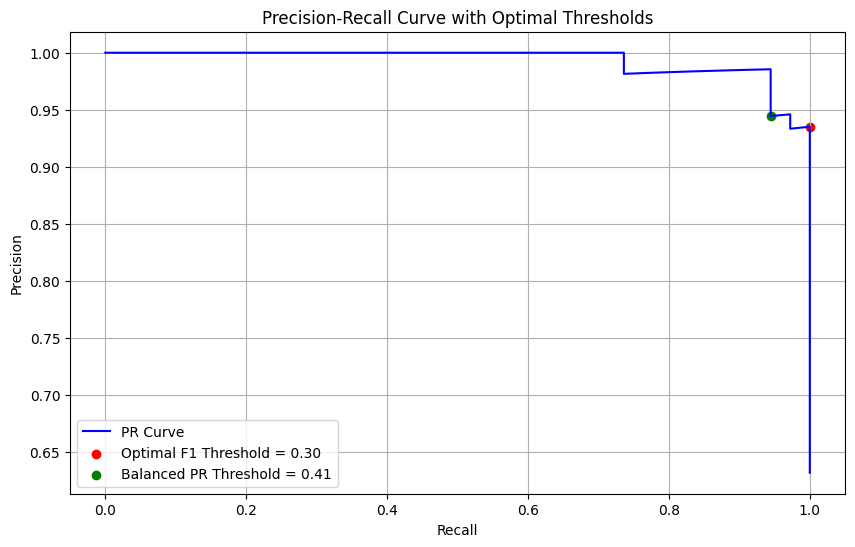

In [24]:
def find_optimal_threshold(y_true, y_prob):
    """
    Finds the optimal threshold based on F1 score and provides insights using PR curve.

    Parameters:
    - y_true: array-like, ground truth binary labels (0 or 1)
    - y_prob: array-like, predicted scores or probabilities for the positive class

    Returns:
    - optimal_thresholds: dict with optimal thresholds for F1 score and PR curve insights
    """
    # Calculate precision, recall, thresholds for PR Curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    # Method 1: Using F1 score
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)  # Avoid division by zero
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold_f1 = thresholds[optimal_idx]

    # Method 2: Midpoint of precision and recall (if you want balanced precision and recall)
    pr_diff = np.abs(precision - recall)
    optimal_idx_pr = np.argmin(pr_diff)
    optimal_threshold_pr_balance = thresholds[optimal_idx_pr]

    # Collect results
    optimal_thresholds = {
        "F1_score": optimal_threshold_f1,
        "Precision-Recall_Balance": optimal_threshold_pr_balance
    }

    # Plot Precision-Recall curve with marked optimal thresholds
    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, label='PR Curve', color='blue')
    plt.scatter(recall[optimal_idx], precision[optimal_idx], color='red',
                label=f'Optimal F1 Threshold = {optimal_threshold_f1:.2f}')
    plt.scatter(recall[optimal_idx_pr], precision[optimal_idx_pr], color='green',
                label=f'Balanced PR Threshold = {optimal_threshold_pr_balance:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Optimal Thresholds')
    plt.legend(loc='lower left')
    plt.grid()
    plt.show()

    return optimal_thresholds

optimal_thresholds = find_optimal_threshold(y_test, y_proba)

### Youden's J Statistic (Optimal ROC Threshold)

In [25]:
def optimal_threshold_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]
    print(f"Optimal Threshold (Youden's J): {optimal_threshold:.2f}")
    return optimal_threshold

optimal_threshold = optimal_threshold_youden(y_test, y_proba)

# Adjust predictions based on the optimal threshold
y_hat_adj = (y_proba > optimal_threshold).astype(int)

# Classification report with adjusted threshold
print("Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_hat_adj, target_names=data.target_names))

print("Classification Report with Default Threshold (0.5):")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

Optimal Threshold (Youden's J): 0.51
Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

   malignant       0.89      0.98      0.93        42
      benign       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

Classification Report with Default Threshold (0.5):
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



#### Maximizing Specificity and Sensitivity Balance

In [26]:
def optimal_threshold_sensitivity_specificity(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    specificity = 1 - fpr
    balance = np.abs(specificity - tpr)
    optimal_idx = np.argmin(balance)
    optimal_threshold = thresholds[optimal_idx]
    print(f"Optimal Threshold (Sensitivity-Specificity Balance): {optimal_threshold:.2f}")
    return optimal_threshold

optimal_threshold_balance = optimal_threshold_sensitivity_specificity(y_test, y_proba)

Optimal Threshold (Sensitivity-Specificity Balance): 0.51




---



# Conclusion

In this practical session, we explored the **Logistic Regression classifier** using the Breast Cancer dataset. We covered:

1. **Data Loading and Preprocessing**: Including scaling, which is crucial for Logistic Regression.
2. **Model Implementation and Hyperparameter Tuning**: Finding the optimal regularization parameter (`C`).
3. **Advanced Variations**: Exploring different regularization techniques to enhance model performance.
4. **Model Evaluation Metrics**: Using ROC, Precision-Recall curves, and finding the best threshold for decision-making.
5. **Statistical Insights with Statsmodels**: Interpreting coefficients, p-values, and understanding the statistical significance of features.
6. **Feature Importance**: Using coefficient magnitudes, permutation importance, and p-values to understand which features influence the model the most.

Logistic Regression is a simple yet powerful algorithm that provides a good foundation for understanding more complex machine learning concepts. It emphasizes the importance of data preprocessing, hyperparameter tuning, and interpretability. Moreover, it highlights the importance of carefully choosing the right evaluation metrics and decision thresholds, particularly in sensitive applications like healthcare.

Feel free to explore further by experimenting with different parameter settings and variations to gain a deeper understanding of the algorithm. Remember that practice is the key to mastering these concepts, and the more you experiment, the more insights you'll gain.


# References



*   scikit-learn Documentation Logistic Regression: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
*   Statsmodels Documentation: https://www.statsmodels.org/stable/index.html



# 7. (Optional) Logistic Regression with Statsmodels

`statsmodels` provides a different interface for statistical modeling, offering detailed summaries including p-values, confidence intervals, and more.


## 7.1 Installation (if not already installed)

In [27]:
!pip install statsmodels

## 7.2 Implementing Logistic Regression with Statsmodels

In [28]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import statsmodels.api as sm

# Load the Breast Cancer dataset
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Step 1: Basic Preprocessing - Scaling the Features
# Standardize the features using StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(columns=['target']))

# Create a new DataFrame with scaled features
scaled_df = pd.DataFrame(scaled_features, columns=data.feature_names)
scaled_df['target'] = df['target']

# Step 2: Removing Highly Correlated Features
# Calculate the correlation matrix
correlation_matrix = scaled_df.corr().abs()

# Create an upper triangle matrix to filter highly correlated features
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Set a correlation threshold for dropping features
correlation_threshold = 0.9

# Find features with correlation greater than the threshold
high_correlation_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]

# Drop highly correlated features from the dataset
filtered_df = scaled_df.drop(columns=high_correlation_features)

# Step 3: Train-Test Split
# Define features and target
X = filtered_df.drop(columns=['target'])
y = filtered_df['target']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add a constant term to the features for the intercept
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Step 4: Fitting the Logistic Regression Model
# Fit the logistic regression model using statsmodels
logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit()

# Display the summary of the logistic regression
print(result.summary())

# Step 5: Model Evaluation - Predictions, Accuracy, and Confusion Matrix
# Predict the probabilities of the test set
y_pred_prob = result.predict(X_test)

# Convert probabilities to binary outcomes (0 or 1) using a threshold of 0.5
y_pred = [1 if prob > 0.5 else 0 for prob in y_pred_prob]

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Optional: Analyzing the Coefficients
coefficients = result.params
p_values = result.pvalues
confidence_intervals = result.conf_int()

# Print key coefficients information
print("\nCoefficients:")
print(coefficients)

print("\nP-values:")
print(p_values)

print("\nConfidence Intervals:")
print(confidence_intervals)

# Optional analysis: Check significant predictors
significant_vars = coefficients[p_values < 0.05]
print("\nSignificant Predictors at 5% level:")
print(significant_vars)


Optimization terminated successfully.
         Current function value: 0.034995
         Iterations 15
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  455
Model:                          Logit   Df Residuals:                      434
Method:                           MLE   Df Model:                           20
Date:                Sat, 02 Nov 2024   Pseudo R-squ.:                  0.9470
Time:                        03:09:29   Log-Likelihood:                -15.923
converged:                       True   LL-Null:                       -300.17
Covariance Type:            nonrobust   LLR p-value:                1.233e-107
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       2.2748      1.572      1.447      0.148      -0.807  

## 7.3 Interpretation of Statsmodels Results

`statsmodels` provides detailed statistical information about the model:

- **Coefficients (`coef`)**: Represents the log-odds change for a one-unit increase in the predictor.
- **Standard Errors (`std err`)**: Measure the variability of the coefficient estimates.
- **z-values and p-values**: Test the null hypothesis that the coefficient is zero (no effect).
- **Confidence Intervals**: Range within which the true coefficient value lies with a certain probability.



---



In [29]:
accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.51


# 8. (Optional) Feature Importance

Understanding which features contribute most to the model's predictions is essential for interpretation, feature selection, and gaining insights into the data. Below are various methods to assess feature importance in Logistic Regression.


## 8.1 Coefficient Magnitudes

In Logistic Regression, the absolute values of the coefficients indicate the strength of the association between each feature and the target variable. Larger absolute values imply greater importance.

### 8.1.1 Visualizing Feature Coefficients

<ipython-input-30-6f9876e5c4c2>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients_sorted.values, y=coefficients_sorted.index, palette='viridis')


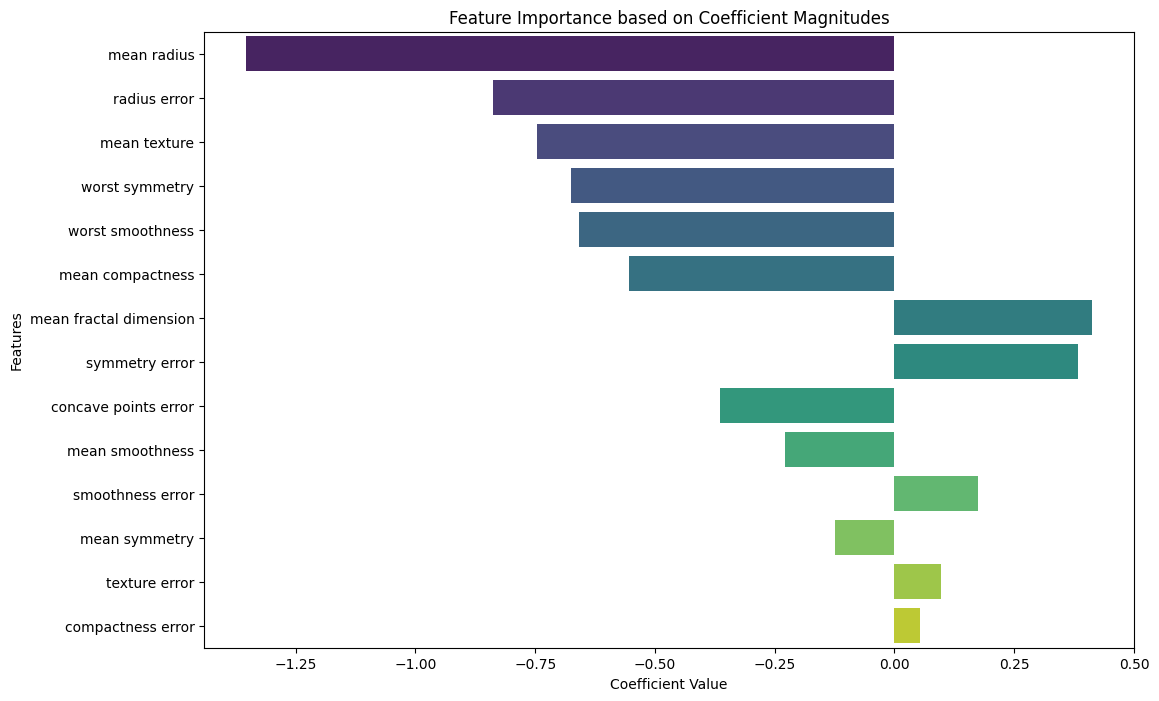

In [30]:
# Extract coefficients from the best Logistic Regression model
coefficients_best = pd.Series(logreg_best.coef_[0], index=X_train_reduced.columns)

# Sort coefficients by absolute value
coefficients_sorted = coefficients_best.reindex(coefficients_best.abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=coefficients_sorted.values, y=coefficients_sorted.index, palette='viridis')
plt.title('Feature Importance based on Coefficient Magnitudes')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

### 8.1.2 Top Positive and Negative Features

Top 10 Descending Features:
mean fractal dimension    0.412189
symmetry error            0.382175
smoothness error          0.174983
texture error             0.096248
compactness error         0.052407
mean symmetry            -0.124432
mean smoothness          -0.229142
concave points error     -0.364407
mean compactness         -0.555051
worst smoothness         -0.659325
dtype: float64

Top 10 Ascending Features:
mean radius            -1.352752
radius error           -0.837449
mean texture           -0.745554
worst symmetry         -0.675997
worst smoothness       -0.659325
mean compactness       -0.555051
concave points error   -0.364407
mean smoothness        -0.229142
mean symmetry          -0.124432
compactness error       0.052407
dtype: float64


<ipython-input-31-bc4a45a4085e>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_positive.values, y=top_positive.index, palette='tab10')
<ipython-input-31-bc4a45a4085e>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_negative.values, y=top_negative.index, palette='tab10')


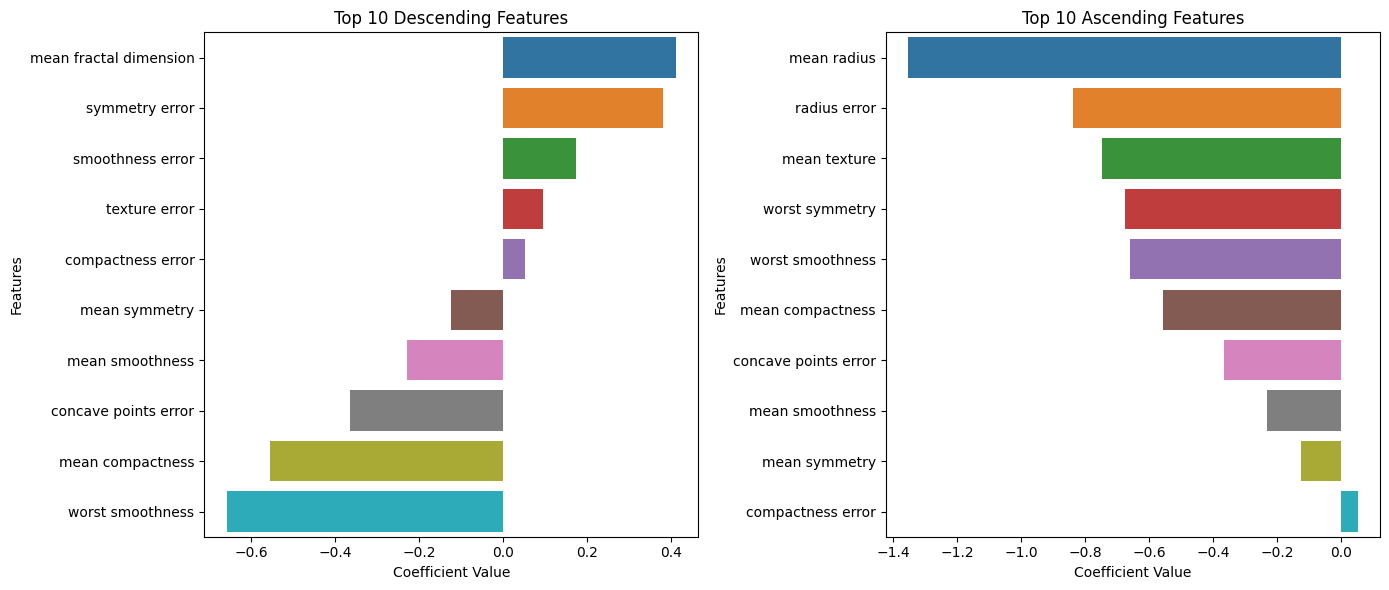

In [31]:
# Top 10 Descending coefficients
top_positive = coefficients_best.sort_values(ascending=False).head(10)
print("Top 10 Descending Features:")
print(top_positive)

# Top 10 negative coefficients
top_negative = coefficients_best.sort_values().head(10)
print("\nTop 10 Ascending Features:")
print(top_negative)

# Plotting top positive and negative features
plt.figure(figsize=(14, 6))

# Positive features
plt.subplot(1, 2, 1)
sns.barplot(x=top_positive.values, y=top_positive.index, palette='tab10')
plt.title('Top 10 Descending Features')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')

# Negative features
plt.subplot(1, 2, 2)
sns.barplot(x=top_negative.values, y=top_negative.index, palette='tab10')
plt.title('Top 10 Ascending Features')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

## 8.2 Permutation Importance

Permutation Importance measures the increase in the model's prediction error when a single feature's values are randomly shuffled. It provides insight into how each feature affects the model's performance.


<ipython-input-32-c0b973b47e27>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


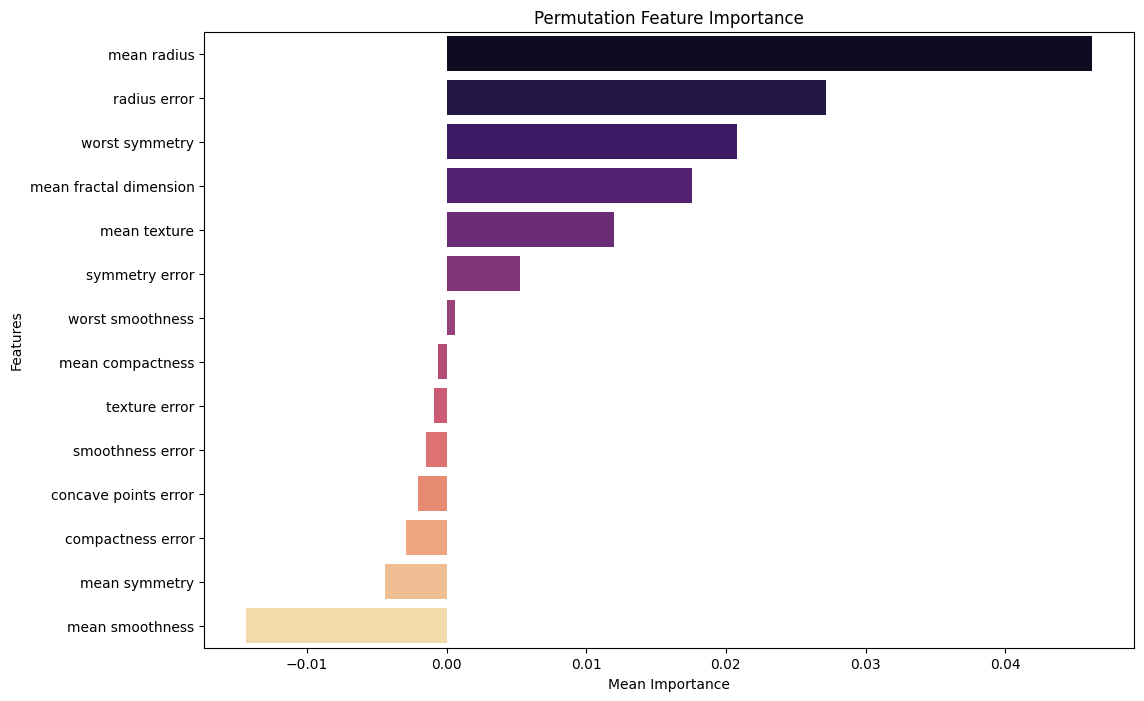

In [32]:
# Compute permutation importance on the best model
perm_importance = permutation_importance(
    logreg_best, X_test_scaled, y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

# Create a DataFrame for feature importance
perm_importance_df = pd.DataFrame({
    'Feature': X_test_reduced.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values(by='Importance Mean', ascending=False)

# Plot permutation importance
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance Mean',
    y='Feature',
    data=perm_importance_df,
    palette='magma'
)
plt.title('Permutation Feature Importance')
plt.xlabel('Mean Importance')
plt.ylabel('Features')
plt.show()

## 8.3 Feature Importance from Statsmodels

Using `statsmodels`, you can assess the statistical significance of each feature through p-values.

**Features with lower p-values are considered more significant.**


<ipython-input-33-51f31af25d2c>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=p_values_sorted.values, y=p_values_sorted.index, palette='coolwarm')


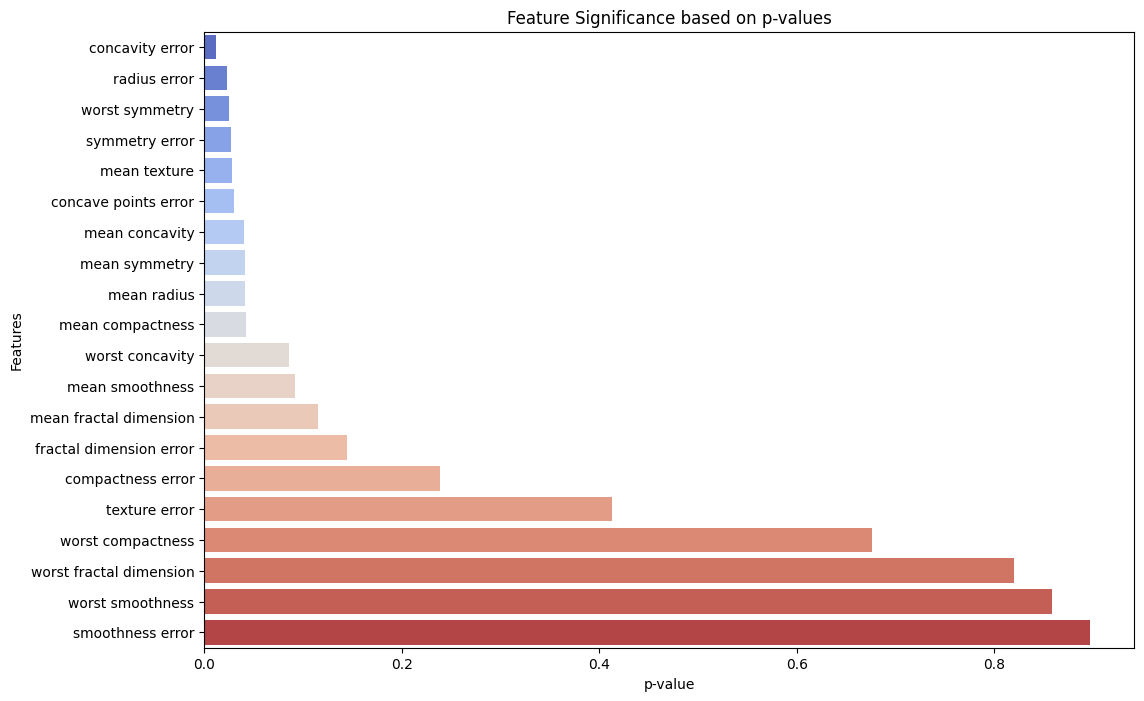

Significant Features (p < 0.05):
concavity error         0.012408
radius error            0.023299
worst symmetry          0.025274
symmetry error          0.027295
mean texture            0.027837
concave points error    0.030473
mean concavity          0.040401
mean symmetry           0.041661
mean radius             0.041748
mean compactness        0.042833
dtype: float64


In [33]:
# Extract p-values from statsmodels result
p_values = result.pvalues.drop('const')  # Exclude intercept

# Sort features by p-value
p_values_sorted = p_values.sort_values()

# Plot p-values
plt.figure(figsize=(12, 8))
sns.barplot(x=p_values_sorted.values, y=p_values_sorted.index, palette='coolwarm')
plt.title('Feature Significance based on p-values')
plt.xlabel('p-value')
plt.ylabel('Features')
plt.show()

# Highlight significant features (e.g., p < 0.05)
significant_features = p_values_sorted[p_values_sorted < 0.05]
print("Significant Features (p < 0.05):")
print(significant_features)